---
# LAB 4: Data Wrangling, ETL & Exploratory Data Analysis (EDA)

### Dataset Generation

In [ ]:
!pip install faker

In [ ]:
import pandas as pd
import numpy as np
import random
from faker import Faker

fake = Faker()
np.random.seed(42)
random.seed(42)
n = 100

data = {
    'Date': [fake.date_this_decade() if random.random() > 0.1 else None for _ in range(n)],
    'CustomerID': [random.randint(1000, 9999) if random.random() > 0.05 else None for _ in range(n)],
    'Product': [random.choice(['Laptop', 'Phone', 'Tablet', 'Monitor', 'Keyboard', 'Headphones', 'Mouse']) for _ in range(n)],
    'Category': [random.choice(['Electronics', 'Furniture', 'Toys', 'Clothing', 'Sports']) for _ in range(n)],
    'Sales': [round(random.uniform(50, 1500), 2) if random.random() > 0.1 else None for _ in range(n)],
}

df = pd.DataFrame(data)
df['Product'] = df['Product'].where(np.random.random(len(df)) > 0.1, None)
df = pd.concat([df, df.sample(frac=0.05, random_state=42)], ignore_index=True)
df.to_csv('sales_data.csv', index=False)
print(df.head())
print(df.info())

         Date  CustomerID     Product     Category    Sales
0  2025-07-06         NaN      Laptop  Electronics  1297.64
1        None      9797.0  Headphones         Toys  1178.71
2  2025-12-04      6573.0     Monitor         Toys  1215.96
3  2022-01-31      8123.0       Mouse       Sports   723.60
4  2024-06-21      1053.0      Tablet     Clothing  1380.33
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Date        91 non-null     object 
 1   CustomerID  100 non-null    float64
 2   Product     91 non-null     object 
 3   Category    105 non-null    object 
 4   Sales       97 non-null     float64
dtypes: float64(2), object(3)
memory usage: 4.2+ KB
None


### Data Wrangling (ETL: Extract Transform, Load)

In [ ]:
df = pd.read_csv('sales_data.csv')
print(df.head())
print("\nMissing values:\n", df.isnull().sum())

         Date  CustomerID     Product     Category    Sales
0  2025-07-06         NaN      Laptop  Electronics  1297.64
1         NaN      9797.0  Headphones         Toys  1178.71
2  2025-12-04      6573.0     Monitor         Toys  1215.96
3  2022-01-31      8123.0       Mouse       Sports   723.60
4  2024-06-21      1053.0      Tablet     Clothing  1380.33

Missing values:
 Date          14
CustomerID     5
Product       14
Category       0
Sales          8
dtype: int64


In [ ]:
# Handle missing data
df['Sales'] = df['Sales'].fillna(df['Sales'].median())
df = df.dropna()

# Correct data types
df['Date'] = pd.to_datetime(df['Date'])
df['Category'] = df['Category'].astype('category')

# Remove duplicates
df = df.drop_duplicates()
df = df.drop_duplicates(subset=['CustomerID', 'Product'])

# Feature Engineering: extract year and month
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# Normalize Sales
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df['Sales_scaled'] = scaler.fit_transform(df[['Sales']])

# Save cleaned data
df.to_csv('cleaned_sales_data.csv', index=False)
df.head()

,Date,CustomerID,Product,Category,Sales,Year,Month,Sales_scaled
2,2025-12-04,6573.0,Monitor,Toys,1215.96,2025,12,0.804341
3,2022-01-31,8123.0,Mouse,Sports,723.60,2022,1,0.459254
4,2024-06-21,1053.0,Tablet,Clothing,1380.33,2024,6,0.919546
5,2023-10-09,5315.0,Laptop,Sports,243.34,2023,10,0.122648
8,2024-09-23,5889.0,Mouse,Electronics,691.73,2024,9,0.436917


### Exploratory Data Analysis (EDA)

                                Date   CustomerID        Sales         Year  \
count                             71    71.000000    71.000000    71.000000   
mean   2022-12-25 21:38:01.690140928  5204.225352   816.256338  2022.521127   
min              2020-02-16 00:00:00  1053.000000    68.350000  2020.000000   
25%              2021-07-12 00:00:00  2811.000000   490.945000  2021.000000   
50%              2022-10-13 00:00:00  5033.000000   852.540000  2022.000000   
75%              2024-04-29 12:00:00  6813.500000  1192.470000  2024.000000   
max              2026-02-09 00:00:00  9883.000000  1495.120000  2026.000000   
std                              NaN  2518.933097   406.260119     1.654942   

           Month  Sales_scaled  
count  71.000000     71.000000  
mean    6.042254      0.524195  
min     1.000000      0.000000  
25%     3.000000      0.296190  
50%     6.000000      0.549626  
75%     9.000000      0.787878  
max    12.000000      1.000000  
std     3.506877      0.

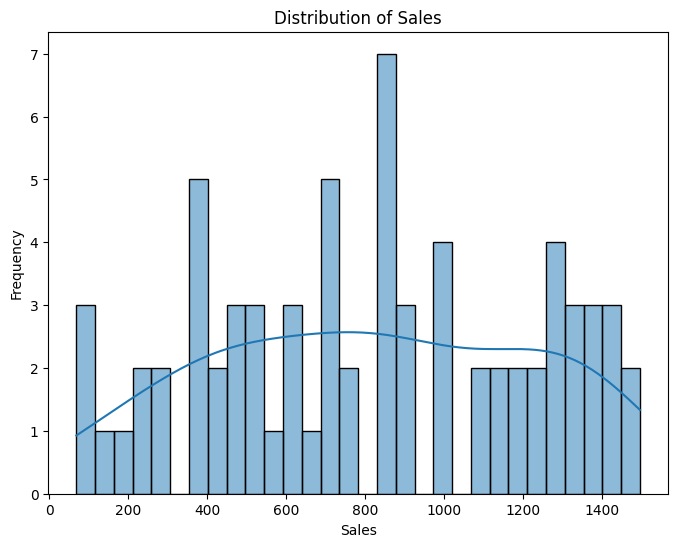

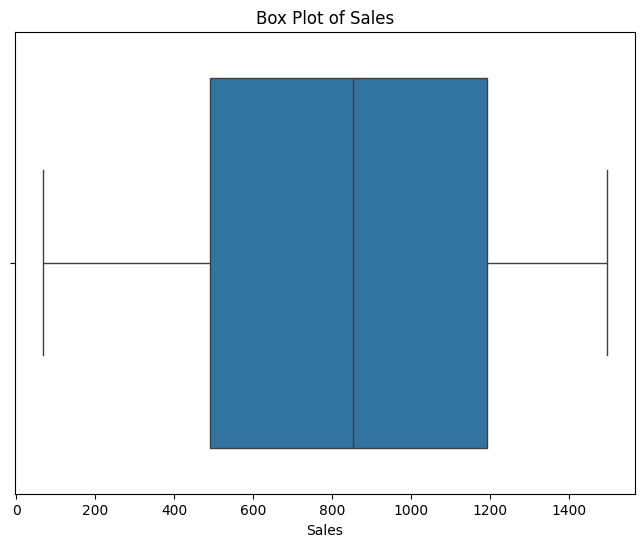

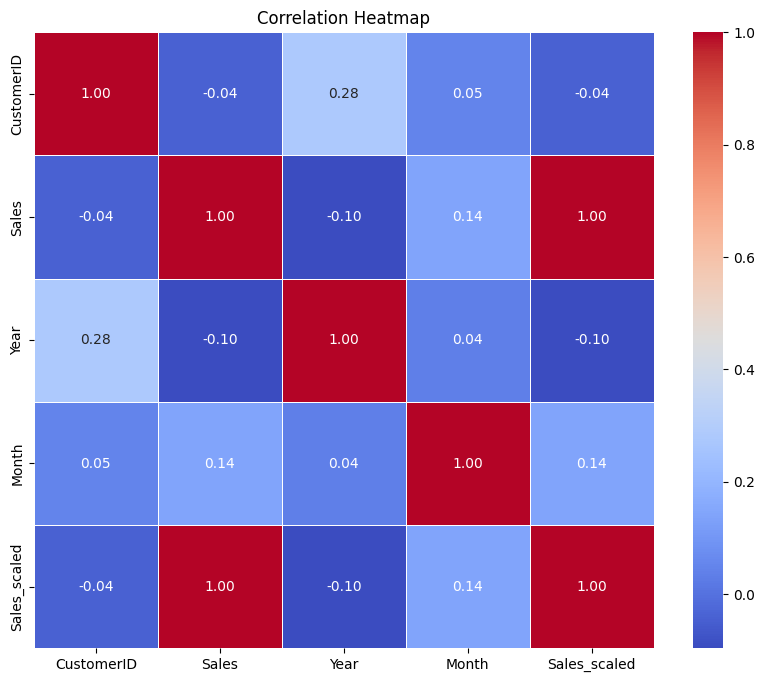

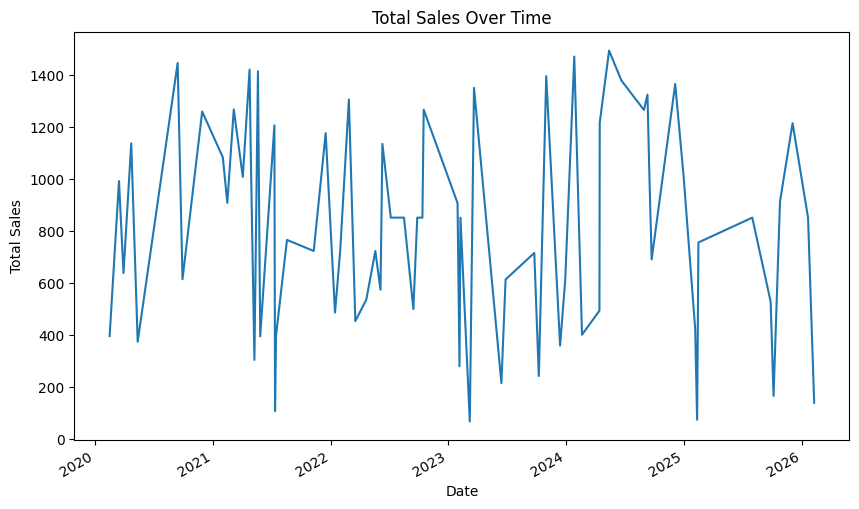

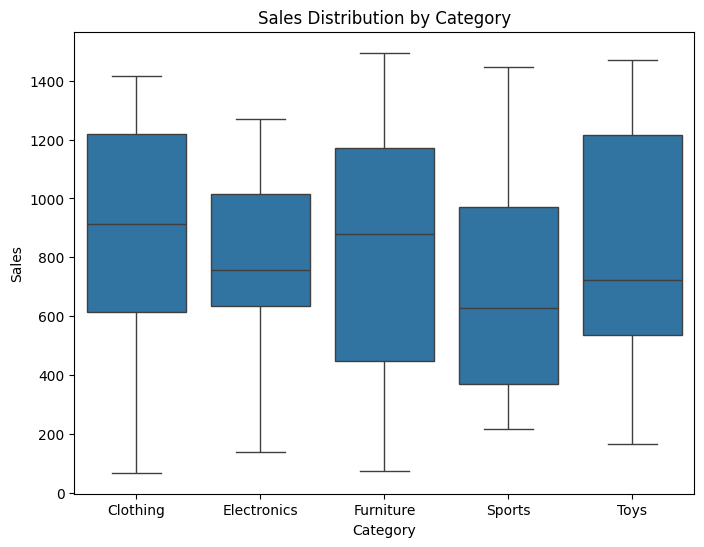

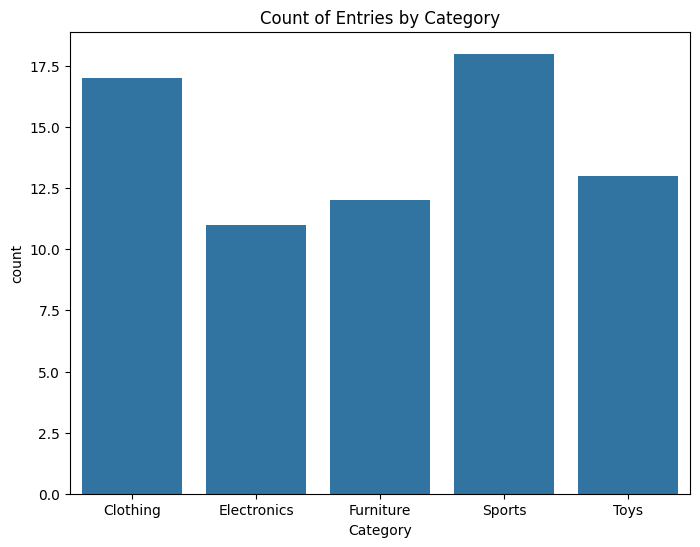

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print(df.describe())
print(df['Category'].value_counts())

# Histogram
plt.figure(figsize=(8, 6))
sns.histplot(df['Sales'], bins=30, kde=True)
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

# Box plot
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['Sales'])
plt.title('Box Plot of Sales')
plt.show()

# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=np.number).corr(),
            annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

# Sales over time
plt.figure(figsize=(10, 6))
df.groupby('Date')['Sales'].sum().plot()
plt.title('Total Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.show()

# Sales by category
plt.figure(figsize=(8, 6))
sns.boxplot(x='Category', y='Sales', data=df)
plt.title('Sales Distribution by Category')
plt.show()

plt.figure(figsize=(8, 6))
sns.countplot(x='Category', data=df)
plt.title('Count of Entries by Category')
plt.show()

### EDA with Telecom Churn Dataset

(3333, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   3333 non-null   object 
 1   Account length          3333 non-null   int64  
 2   Area code               3333 non-null   int64  
 3   International plan      3333 non-null   object 
 4   Voice mail plan         3333 non-null   object 
 5   Number vmail messages   3333 non-null   int64  
 6   Total day minutes       3333 non-null   float64
 7   Total day calls         3333 non-null   int64  
 8   Total day charge        3333 non-null   float64
 9   Total eve minutes       3333 non-null   float64
 10  Total eve calls         3333 non-null   int64  
 11  Total eve charge        3333 non-null   float64
 12  Total night minutes     3333 non-null   float64
 13  Total night calls       3333 non-null   int64  
 14  Total night charge      3333 

/tmp/ipykernel_6264/2527473105.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({"Voice mail plan": d})


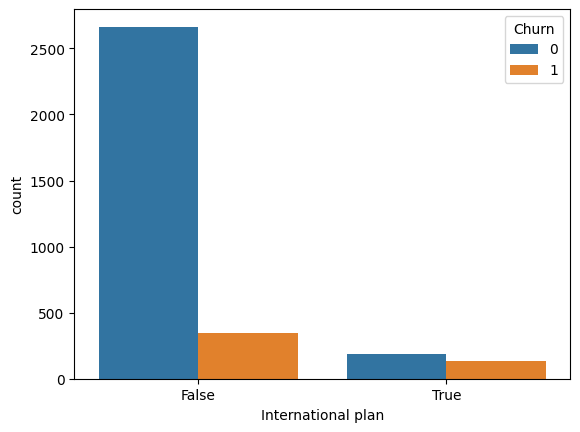

International plan  False  True 
Churn                           
0                    2664    186
1                     346    137
Customer service calls    0     1    2    3    4   5   6  7  8  9   All
Churn                                                                  
0                       605  1059  672  385   90  26   8  4  1  0  2850
1                        92   122   87   44   76  40  14  5  1  2   483
All                     697  1181  759  429  166  66  22  9  2  2  3333


In [ ]:
DATA_URL = "https://raw.githubusercontent.com/Yorko/mlcourse.ai/main/data/"
df = pd.read_csv(DATA_URL + "telecom_churn.csv")
print(df.shape)
df.head()

print(df.info())
print(df.describe())

df["Churn"] = df["Churn"].astype("int64")
print(df["Churn"].value_counts())

d = {"No": False, "Yes": True}
df["International plan"] = df["International plan"].map(d)
df = df.replace({"Voice mail plan": d})

sns.countplot(x="International plan", hue="Churn", data=df)
plt.show()

print(pd.crosstab(df["Churn"], df["International plan"]))
print(pd.crosstab(df["Churn"], df["Customer service calls"], margins=True))

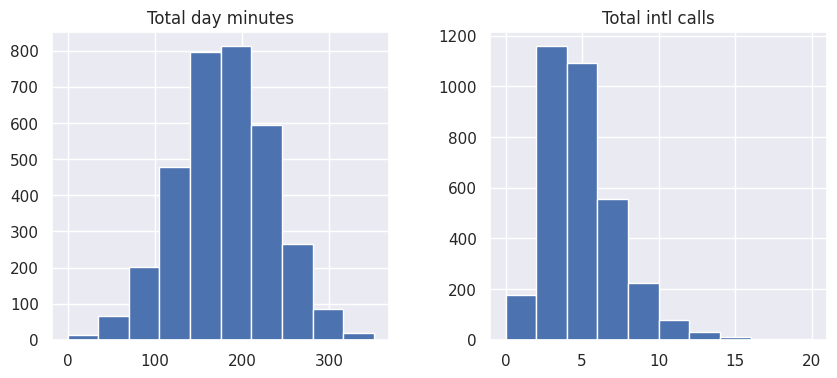

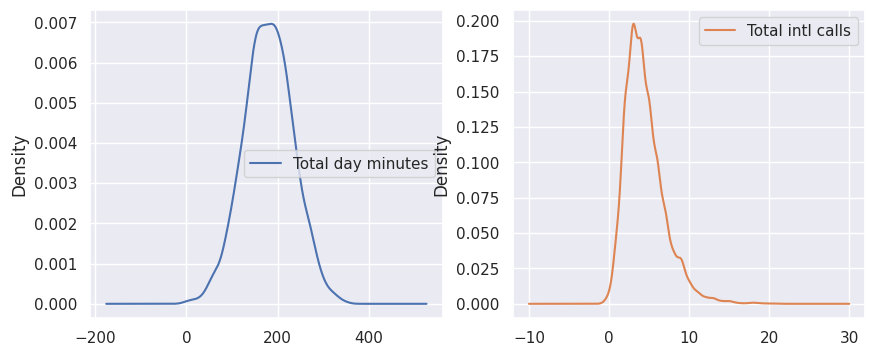

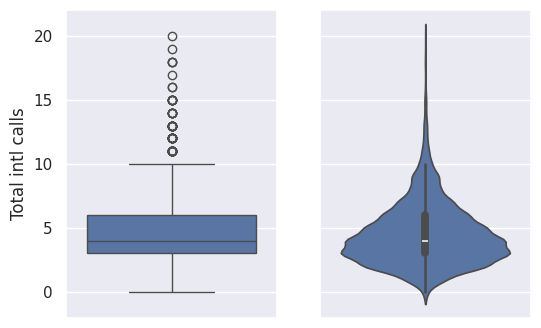

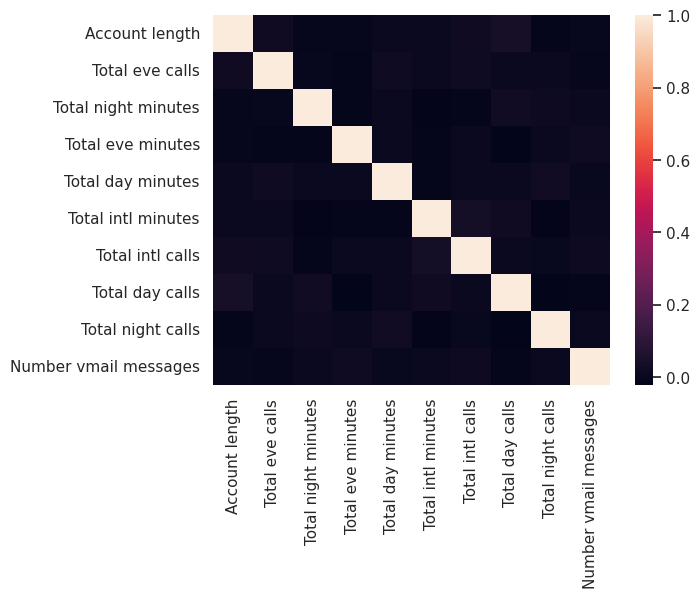

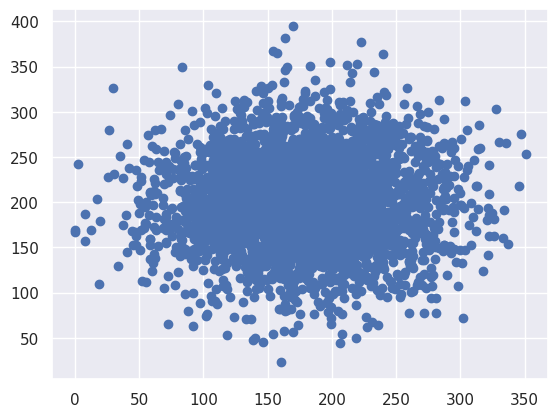

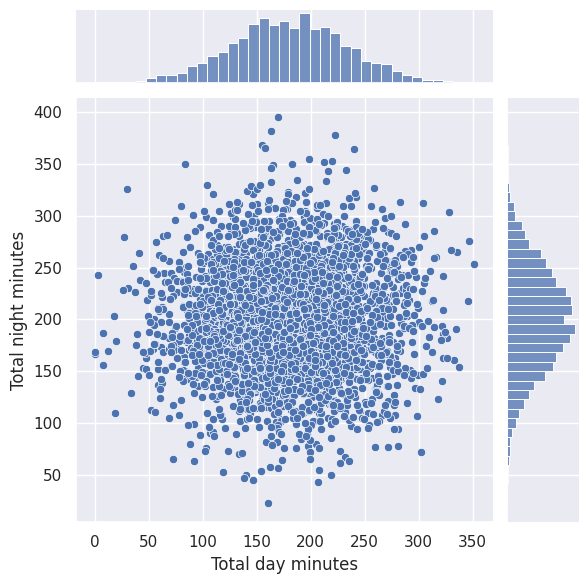

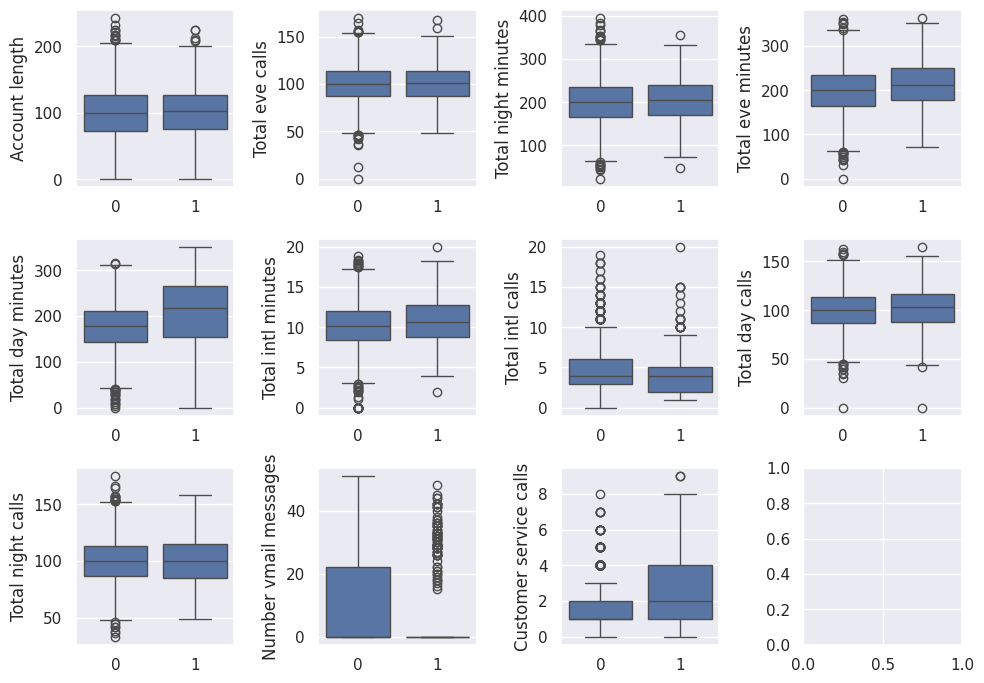

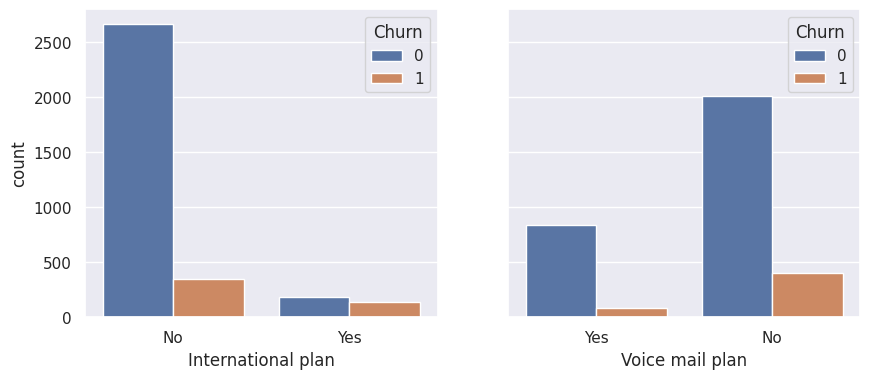

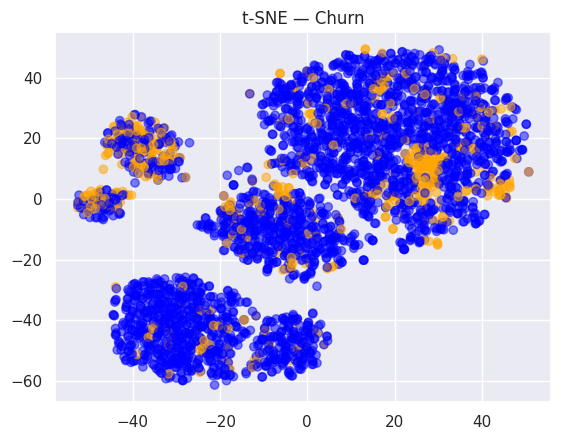